# Data cleaning

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
# Import dataset into our pipeline
df = pd.read_csv(r'boxoffice.csv')

In [3]:
# Display all rows from a-z
pd.set_option('display.max_rows', None)
df

,title,domestic_revenue,world_revenue,distributor,opening_revenue,opening_theaters,budget,MPAA,genres,release_days
0,The Avengers,6026491,1274885664,Warner Bros.,163620146,253,174687337,R,Animation,16
1,Titanic,169411543,1132871091,Disney,85549990,122,103948486,G,Action,103
2,Jurassic Park,107836098,583329845,Sony,55681429,3826,122104991,NC-17,Horror,89
3,Avatar,51433697,1225323391,Disney,109775324,3868,46431596,G,Horror,85
4,The Lion King,142791649,604140729,Warner Bros.,59476800,2934,203513696,R,Comedy,158
5,Star Wars,283757629,1334675706,Universal,17256584,1216,39257068,R,Comedy,154
6,Frozen,37740374,574288068,Sony,173129561,4472,81033758,NC-17,Action,47
7,Inception,185260781,220079595,Paramount,102102678,3548,299859703,PG-13,Drama,44
8,The Dark Knight,237676543,966307844,Warner Bros.,60993059,1813,185463573,R,Action,9
9,Harry Potter,3891150,483144971,Universal,16494184,1454,20168236,PG,Horror,152


In [4]:
# Size of dataset
df.size

26940

In [5]:
# Big picture overview of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2694 entries, 0 to 2693
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             2694 non-null   object
 1   domestic_revenue  2694 non-null   int64 
 2   world_revenue     2694 non-null   int64 
 3   distributor       2694 non-null   object
 4   opening_revenue   2694 non-null   int64 
 5   opening_theaters  2694 non-null   int64 
 6   budget            2694 non-null   int64 
 7   MPAA              2694 non-null   object
 8   genres            2694 non-null   object
 9   release_days      2694 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 210.6+ KB


In [6]:
# Statistical description of dataset\
df.describe()

,domestic_revenue,world_revenue,opening_revenue,opening_theaters,budget,release_days
count,2.694000e+03,2.694000e+03,2.694000e+03,2694.000000,2.694000e+03,2694.000000
mean,1.508539e+08,7.719177e+08,9.971321e+07,2263.039347,1.537996e+08,90.897550
std,8.579997e+07,4.284414e+08,5.721762e+07,1298.559140,8.557624e+07,50.894041
min,8.277650e+05,3.261301e+06,1.385690e+05,10.000000,5.197977e+06,1.000000
25%,7.673272e+07,3.991135e+08,5.033848e+07,1161.000000,7.861876e+07,47.000000
50%,1.525725e+08,7.665551e+08,9.981418e+07,2271.500000,1.562567e+08,91.000000
75%,2.247314e+08,1.143920e+09,1.489805e+08,3392.250000,2.274832e+08,135.000000
max,2.998107e+08,1.499310e+09,1.999336e+08,4499.000000,2.998597e+08,179.000000


## Missing values 

In [7]:
# Check for the total number of missing values in each column
df.isna().sum()

title               0
domestic_revenue    0
world_revenue       0
distributor         0
opening_revenue     0
opening_theaters    0
budget              0
MPAA                0
genres              0
release_days        0
dtype: int64

## Duplicate data points

In [8]:
# Check for the total number of duplicate data points
df.duplicated().sum()

np.int64(0)

## Standardization check

This involves identifying whether all categorical column values follow a consistent format. That way, if they do not, they can easily and quickly be rectified.

In [9]:
df.distributor.unique()

array(['Warner Bros.', 'Disney', 'Sony', 'Universal', 'Paramount'],
      dtype=object)

In [10]:
df.MPAA.unique()

array(['R', 'G', 'NC-17', 'PG-13', 'PG'], dtype=object)

In [11]:
df.genres.unique()

array(['Animation', 'Action', 'Horror', 'Comedy', 'Drama', 'Thriller'],
      dtype=object)

# Basic Calculations

In [12]:
df

,title,domestic_revenue,world_revenue,distributor,opening_revenue,opening_theaters,budget,MPAA,genres,release_days
0,The Avengers,6026491,1274885664,Warner Bros.,163620146,253,174687337,R,Animation,16
1,Titanic,169411543,1132871091,Disney,85549990,122,103948486,G,Action,103
2,Jurassic Park,107836098,583329845,Sony,55681429,3826,122104991,NC-17,Horror,89
3,Avatar,51433697,1225323391,Disney,109775324,3868,46431596,G,Horror,85
4,The Lion King,142791649,604140729,Warner Bros.,59476800,2934,203513696,R,Comedy,158
5,Star Wars,283757629,1334675706,Universal,17256584,1216,39257068,R,Comedy,154
6,Frozen,37740374,574288068,Sony,173129561,4472,81033758,NC-17,Action,47
7,Inception,185260781,220079595,Paramount,102102678,3548,299859703,PG-13,Drama,44
8,The Dark Knight,237676543,966307844,Warner Bros.,60993059,1813,185463573,R,Action,9
9,Harry Potter,3891150,483144971,Universal,16494184,1454,20168236,PG,Horror,152


In [13]:
# Compute and display total domestic revenue
total_domestic_revenue = df['domestic_revenue'].sum()

# :, is used to format the amount with commas
print(f'Total domestic revenue across all movies = ${total_domestic_revenue:,}')

Total domestic revenue across all movies = $406,400,368,595


In [14]:
# Compute and display avg world revenue
avg_world_revenue = df['world_revenue'].mean()
print(f'Average world revenue = ${avg_world_revenue:,}')

Average world revenue = $771,917,657.792873


In [15]:
# Compute and display the max budget
max_budget = df['budget'].max()
print(f'Maximum budget = ${max_budget:,}')

Maximum budget = $299,859,703


In [16]:
# Compute the total number of movies
total_movies = len(df['title'])
print(f'Total movies = {total_movies}')

Total movies = 2694


# Conditional Analysis

In [17]:
# Movies with an MPAA rating of PG-13
mpaa_pg13 = len(df[df['MPAA'] == 'PG-13'])
print(f'MPAA PG-13 Rated Movies = {mpaa_pg13}')

MPAA PG-13 Rated Movies = 551


In [18]:
# Movies that earned over 100 million in domestic revenue
rev_of_over_100mil = len(df[df['domestic_revenue'] > 100_000_000])
print(f'Movies with > 100 million in domestic revenue = {rev_of_over_100mil:,}')

Movies with > 100 million in domestic revenue = 1,804


In [19]:
# Calculate the average opening revenue for movies with over 2000 opening theaters
movies_w_over_2000 = df[df['opening_theaters'] > 2000]
avg_opening_revenue = movies_w_over_2000['opening_revenue'].mean()

print(f'Average opening revenue for movies with over 2000 opening theaters = ${avg_opening_revenue:,}')

Average opening revenue for movies with over 2000 opening theaters = $98,893,771.0285146


In [20]:
# Compute how many movies have Action as one of their genres
action_movies_count = len(df[df['genres'] == 'Action'])
print(f'Amount of Action movies = {action_movies_count}')

Amount of Action movies = 455


# Text Processing and Lookup

Splits strings based on whitespaces and pick the first element of the list in the form of a function. The function is then applied to each entry within the title column 

In [21]:
# First word extraction
df['first_word'] = df['title'].apply(lambda x: x.split()[0])
df

,title,domestic_revenue,world_revenue,distributor,opening_revenue,opening_theaters,budget,MPAA,genres,release_days,first_word
0,The Avengers,6026491,1274885664,Warner Bros.,163620146,253,174687337,R,Animation,16,The
1,Titanic,169411543,1132871091,Disney,85549990,122,103948486,G,Action,103,Titanic
2,Jurassic Park,107836098,583329845,Sony,55681429,3826,122104991,NC-17,Horror,89,Jurassic
3,Avatar,51433697,1225323391,Disney,109775324,3868,46431596,G,Horror,85,Avatar
4,The Lion King,142791649,604140729,Warner Bros.,59476800,2934,203513696,R,Comedy,158,The
5,Star Wars,283757629,1334675706,Universal,17256584,1216,39257068,R,Comedy,154,Star
6,Frozen,37740374,574288068,Sony,173129561,4472,81033758,NC-17,Action,47,Frozen
7,Inception,185260781,220079595,Paramount,102102678,3548,299859703,PG-13,Drama,44,Inception
8,The Dark Knight,237676543,966307844,Warner Bros.,60993059,1813,185463573,R,Action,9,The
9,Harry Potter,3891150,483144971,Universal,16494184,1454,20168236,PG,Horror,152,Harry


In [22]:
# Budget class column
# Function to assign a class based on budget value
def find_budget_class (x):
    if x < 50_000_000:
        return 'Low Budget'
    elif (x > 50_000_000) and (x < 100_000_000):
        return 'Mid Budget'
    elif x > 100_000_000:
        return 'High Budget'

# Apply the function to each entry within the budget column
df['budget_class'] = df['budget'].apply(find_budget_class)
df

,title,domestic_revenue,world_revenue,distributor,opening_revenue,opening_theaters,budget,MPAA,genres,release_days,first_word,budget_class
0,The Avengers,6026491,1274885664,Warner Bros.,163620146,253,174687337,R,Animation,16,The,High Budget
1,Titanic,169411543,1132871091,Disney,85549990,122,103948486,G,Action,103,Titanic,High Budget
2,Jurassic Park,107836098,583329845,Sony,55681429,3826,122104991,NC-17,Horror,89,Jurassic,High Budget
3,Avatar,51433697,1225323391,Disney,109775324,3868,46431596,G,Horror,85,Avatar,Low Budget
4,The Lion King,142791649,604140729,Warner Bros.,59476800,2934,203513696,R,Comedy,158,The,High Budget
5,Star Wars,283757629,1334675706,Universal,17256584,1216,39257068,R,Comedy,154,Star,Low Budget
6,Frozen,37740374,574288068,Sony,173129561,4472,81033758,NC-17,Action,47,Frozen,Mid Budget
7,Inception,185260781,220079595,Paramount,102102678,3548,299859703,PG-13,Drama,44,Inception,High Budget
8,The Dark Knight,237676543,966307844,Warner Bros.,60993059,1813,185463573,R,Action,9,The,High Budget
9,Harry Potter,3891150,483144971,Universal,16494184,1454,20168236,PG,Horror,152,Harry,Low Budget


## Functions

In [23]:
# Funtion to compute the amount of movies with a specific genre
def movies_with_a_specific_genre (genre):
    count = 0
    for value in df['genres']:
        if value == genre:
            count += 1
    return f'{genre} Movies: {count}'

print(movies_with_a_specific_genre('Action'))

Action Movies: 455


In [24]:
# Function to compute higher budget movies
def find_higher_budget_movies (budget_values):
    # A Series to store all high budget movies
    high_budget_movies = pd.Series([],[])
    # Checking to see if a movie if high budget then adding it to the Series
    # Enumerate is to return elements and their indices
    for index, budget_value in enumerate(budget_values):
        # Assume high budget is 250,000,000 and above
        if budget_value >= 250_000_000:
            high_budget_movies[f'{index}'] = df.loc[index, 'title']
    # Returning that Series        
    return high_budget_movies

print(find_higher_budget_movies(df['budget']))

7                      Inception
17               Captain America
21                          Coco
23                         X-Men
25                  Forrest Gump
26                          Jaws
37                        Frozen
47                      Iron Man
52                          Coco
53      Pirates of the Caribbean
63                       Titanic
67                     Star Wars
73                  Finding Nemo
79               Captain America
87                  Forrest Gump
96                        Avatar
113      Guardians of the Galaxy
128                The Lion King
129                    Star Wars
142                Batman Begins
146     Pirates of the Caribbean
153                      Mad Max
164                 Harry Potter
171                     Iron Man
180                 Forrest Gump
181                         Jaws
184                      Mad Max
186                 The Avengers
190                The Lion King
192                       Frozen
197       

# Data Visualisation

<Axes: xlabel='distributor', ylabel='world_revenue'>

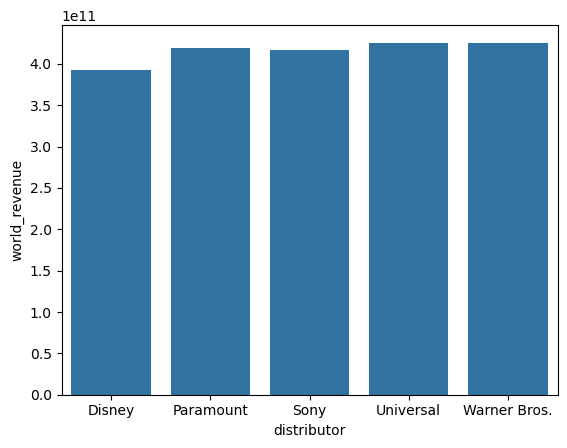

In [25]:
# Obtain total world revenue for each distributor 
distributor_revenue = df.groupby(by='distributor')['world_revenue'].sum()
# Bar chat representation
sns.barplot(data=distributor_revenue)

<Axes: xlabel='budget', ylabel='Count'>

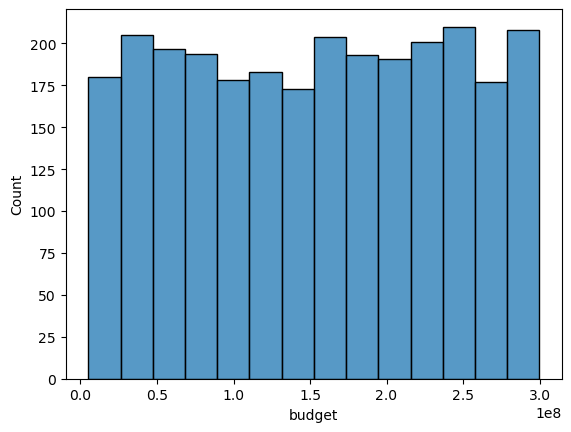

In [26]:
# Create a histplot for movie budget distribution
sns.histplot(df['budget'])

In [27]:
# Display movies with world revenue of over $900M
for index, world_revenue in enumerate(df['world_revenue']):
    # If a movie satisfies condition, it's title and rev. are printed
    if world_revenue > 900_000_000:
        print(f'{df.loc[index,'title']}: ${world_revenue:,}')


The Avengers: $1,274,885,664
Titanic: $1,132,871,091
Avatar: $1,225,323,391
Star Wars: $1,334,675,706
The Dark Knight: $966,307,844
Black Panther: $1,383,183,131
The Godfather: $929,201,322
Shrek: $1,021,285,835
Captain America: $1,313,847,851
Guardians of the Galaxy: $917,589,426
Coco: $1,042,848,073
Jaws: $1,497,543,824
Deadpool: $1,314,234,101
Mad Max: $1,437,542,279
The Avengers: $1,489,393,676
Titanic: $996,654,395
Jurassic Park: $1,324,240,147
Frozen: $1,236,662,606
Inception: $1,259,441,541
Finding Nemo: $1,208,952,339
Black Panther: $1,318,004,659
Shrek: $1,224,051,111
Iron Man: $1,116,640,190
Wonder Woman: $984,207,514
Guardians of the Galaxy: $1,342,579,560
Coco: $976,293,022
Pirates of the Caribbean: $1,443,717,770
The Matrix: $919,493,199
Jaws: $1,167,556,561
Interstellar: $1,498,813,010
Mad Max: $1,400,224,343
The Avengers: $1,491,552,348
Titanic: $1,128,384,875
The Lion King: $1,158,701,204
Toy Story: $1,180,113,280
Spider-Man: $1,355,288,895
Pirates of the Caribbean: $1,

## Lessons learned on the assignment

In [28]:
# Histogram for the distribution of movie budgets
# budget_plot = sns.histplot(data=df, x='title', y='budget')
# Reset the labels on the axis and at the same time rotate them
# THe semicolon is deliberately added to remove unwanted text following plot
# budget_plot.set_xticklabels(budget_plot.get_xticklabels(), rotation=90);